In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator


cytotox_df = pd.read_csv("../data/good/leah_indiv_data/leah_cytotoxicity.csv")

In [11]:
# # Index(['global_id', 'E:T=(X:1)', 'K562-GFP-1', 'K562-GFP-2', 'K562-GFP-3',
# #        'Raji-GFP-1', 'Raji-GFP-2', 'Raji-GFP-3'],
# #       dtype='object')

# cytotox_melted = cytotox_df.melt(id_vars=["global_id", "E:T=(X:1)"],
#                                  value_vars=["K562-GFP-1", "K562-GFP-2", "K562-GFP-3",
#                                              "Raji-GFP-1", "Raji-GFP-2", "Raji-GFP-3"],
#                                  var_name="Target_Replicate",
#                                  value_name="Percent_Cytotoxicity")

# # plot each id separately; scatter plot with error bars (only show mean)
# # make them small and square
# # make the k562 be one color (below fill) and the raji in another color (fill below)

# unique_ids = cytotox_melted['global_id'].unique()
# for uid in unique_ids:





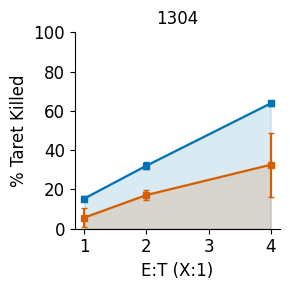

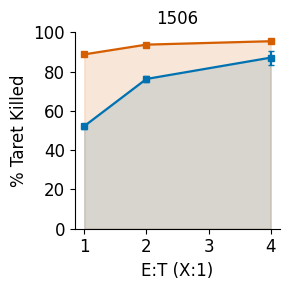

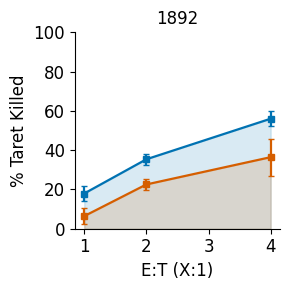

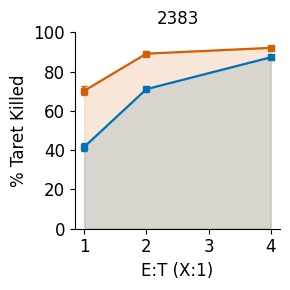

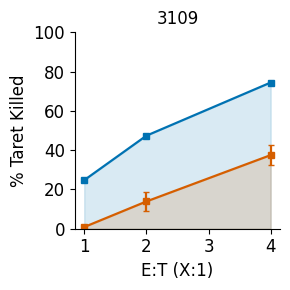

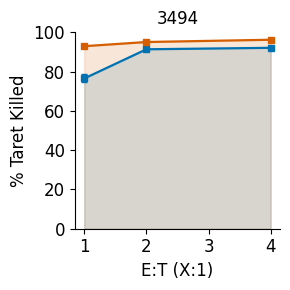

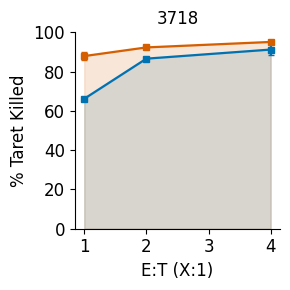

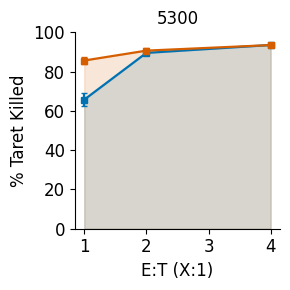

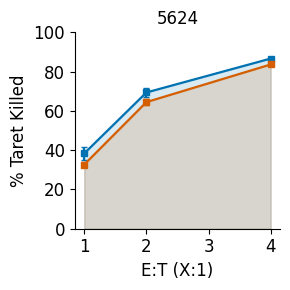

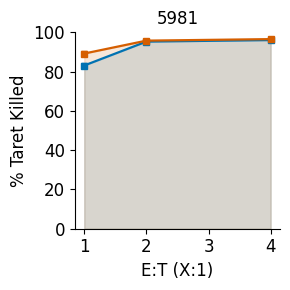

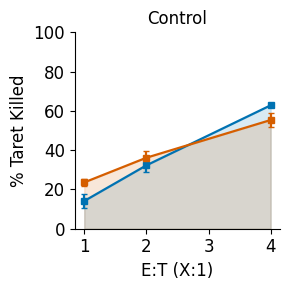

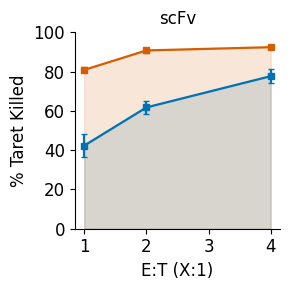

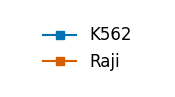

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cytotox_melted = cytotox_df.melt(
    id_vars=["global_id", "E:T=(X:1)"],
    value_vars=[
        "K562-GFP-1", "K562-GFP-2", "K562-GFP-3",
        "Raji-GFP-1", "Raji-GFP-2", "Raji-GFP-3",
    ],
    var_name="Target_Replicate",
    value_name="Percent_Cytotoxicity",
)

cytotox_melted["Target"] = cytotox_melted["Target_Replicate"].str.extract(r"^(K562|Raji)")
cytotox_melted["E:T=(X:1)"] = pd.to_numeric(cytotox_melted["E:T=(X:1)"], errors="coerce")
cytotox_melted["Percent_Cytotoxicity"] = pd.to_numeric(cytotox_melted["Percent_Cytotoxicity"], errors="coerce")

# two clear, high-contrast colors
colors = {"K562": "#0072B2", "Raji": "#D55E00"}  # vermillion, blue

for uid, df_u in cytotox_melted.groupby("global_id"):
    fig, ax = plt.subplots(figsize=(3, 3))

    for target in ["K562", "Raji"]:
        df_t = df_u[df_u["Target"] == target]
        g = df_t.groupby("E:T=(X:1)")["Percent_Cytotoxicity"]
        x = np.array(sorted(g.groups.keys()), dtype=float)
        mean = g.mean().reindex(x).to_numpy()
        sd = g.std(ddof=1).reindex(x).to_numpy()

        ax.fill_between(x, 0, mean, color=colors[target], alpha=0.15)
        ax.errorbar(
            x, mean, yerr=sd,
            fmt="s-", markersize=4, linewidth=1.6,
            capsize=2, color=colors[target],
            label=f"{target}",
        )


    ax.set_title(str(uid))
    ax.set_xlabel("E:T (X:1)", fontsize=12)
    ax.set_ylabel("% Taret Killed", fontsize=12)
    # set tick fontsize to 12
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.set_ylim(0, 100)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"../results/top_ten_plots/cytotoxicity_{uid}.png", bbox_inches="tight", dpi=300)

# save a single legend
fig_legend, ax_legend = plt.subplots(figsize=(2, 1))
for target in ["K562", "Raji"]:
    ax_legend.plot([], [], color=colors[target], label=f"{target}", marker="s", linestyle="-")
legend = ax_legend.legend(frameon=False, fontsize=12, loc="center")
ax_legend.axis("off")
fig_legend.savefig("../results/top_ten_plots/cytotoxicity_legend.png", bbox_inches="tight", dpi=300)